# This notebook differences two timeseries created from 2 dimensional timeseries
## It visualizes the steps through plots, checks correlation, calculates power spectra
### See notebook 2Dtimeseries_1_Visualization_Properties.ipynb for how to handle 2D timeseries
### Example timeseries shown are real data recorded by a RPG-FFTS spectrometer, but any similar dataset can be used

**Loading necessary packages. Please install packages if not present.**

In [1]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator

**Loading the two 2D timeseries files, real data from a noise diode passing through a circuit recorded by a FFT spectrometer**

In [2]:
file1=open('RPGFFTSchanA.spec','r')
file2=open('RPGFFTSchanB.spec','r')

**Loading data into numpy arrays - has specific steps based on datafile - need to adjust based on one's requirements**

In [3]:
# reading in full data
a1 = file1.read()
a2 = file2.read()

# splitting data for each timestamp
s1 = np.array(a1.split('*')[1:])
s2 = np.array(a2.split('*')[1:])

# checking that numbers of timestamps match
if (s1.shape[0]!=s2.shape[0]):
    if(s1.shape[0]>s2.shape[0]):
        s1=s1[:-1]
    else:
        s2=s2[:-1]

# looping over each timestamp row to split data for each channel - and write all of it into 2-d arrays
dum = np.array(s1[0].split('\n'))

spec1 = np.zeros((s1.shape[0]-1,dum.shape[0]-2))
spec2 = np.zeros((s2.shape[0]-1,dum.shape[0]-2))
for i in range(s1.shape[0]-1):
    spec1[i] = np.array(s1[i].split('\n')[1:dum.shape[0]-1])
    spec2[i] = np.array(s2[i].split('\n')[1:dum.shape[0]-1])

# converting data type from float 64 to int 32
spec1.astype(np.int32)
spec2.astype(np.int32)

# calibrating to physical units (milli watts)
ts = 0.1
chans = 8192
spec1=pow(10,(10.00405331*np.log10(spec1/ts)-147.24685047)/10)/chans
spec2=pow(10,(10.00405331*np.log10(spec2/ts)-147.24685047)/10)/chans

/var/folders/_8/scf0b0g13g9f9vr2vtljc8480000gn/T/ipykernel_74735/3985276445.py:26: RuntimeWarning: invalid value encountered in cast
  spec1.astype(np.int32)
/var/folders/_8/scf0b0g13g9f9vr2vtljc8480000gn/T/ipykernel_74735/3985276445.py:27: RuntimeWarning: invalid value encountered in cast
  spec2.astype(np.int32)


**Averaging data along 'time' axis - the actual timeseries - averaging over a range of 'channels'**

In [4]:
chani = 1500
chanf = 6500

plsp1 = np.sum(spec1[:,chani:chanf+1],axis=1)/(chanf-chani+1)
plsp2 = np.sum(spec2[:,chani:chanf+1],axis=1)/(chanf-chani+1)

dc1=np.mean(plsp1)
dc2=np.mean(plsp2)

print('DC level of 1 = {}'.format(dc1))
print('DC level of 2 = {}'.format(dc2))

# modify input 2 gain level to input 1 gain level
plsp2/=dc2
plsp2*=dc1

DC level of 1 = 3.6173917898221936e-05
DC level of 2 = 3.180175391161488e-05


**Confirming that the two 'channel' averaged timeseries are correlated well**

In [5]:
# Calculating Pearson correlation coefficient

pcc = pearsonr(plsp1,plsp2)

print('Pearson correlation coefficient between the 2 timeseries = {}'.format(pcc[0]))

Pearson correlation coefficient between the 2 timeseries = 0.9376480056917477


**Plotting the two channel averaged timeseries**

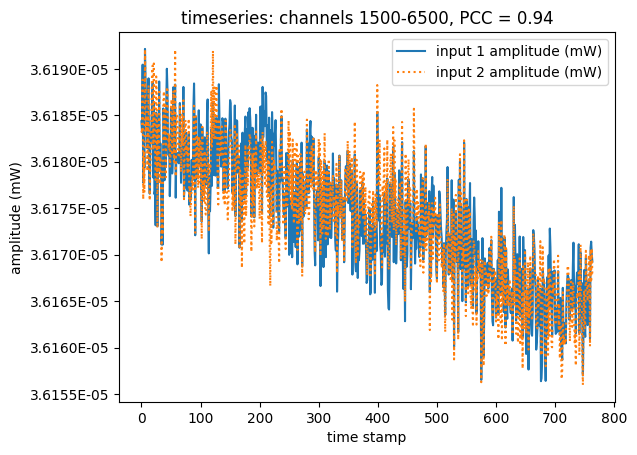

In [6]:
plt.figure()
plt.title('timeseries: channels {}-{}, PCC = {:.2f}'.format(chani,chanf,pcc[0]))
plt.xlabel('time stamp')
plt.ylabel('amplitude (mW)')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4E'))
plt.plot(plsp1,label='input 1 amplitude (mW)')
plt.plot(plsp2,':',label='input 2 amplitude (mW)')
plt.legend()
plt.show()

**Fitting out the base trend (dispersion relation)**

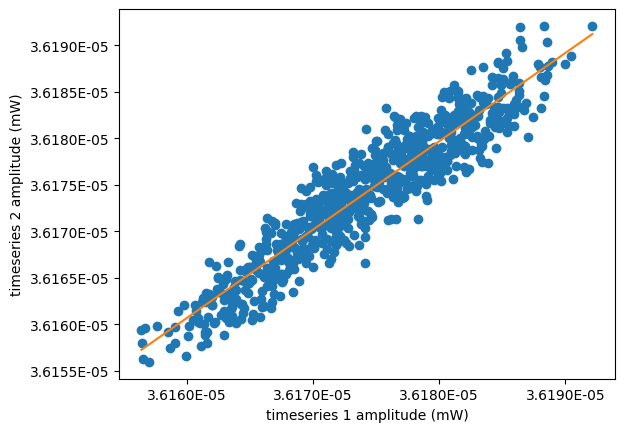

In [7]:
# fitting a straight line to the dispersion relation between the two timeseries

def line(x,m,c):
    return m*x+c

copt, ccov = curve_fit(line, plsp1/dc1, plsp2/dc1)

# plotting the dispersion relation along with the best fit

x=np.linspace(plsp1.min(),plsp1.max(),1000)
y=line(x,copt[0],dc1*copt[1])

plt.figure()
plt.xlabel('timeseries 1 amplitude (mW)')
plt.ylabel('timeseries 2 amplitude (mW)')
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.4E'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.4E'))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=4))
plt.plot(plsp1,plsp2,'o')
plt.plot(x,y)
plt.draw()

**Creating difference timeseries and plotting**

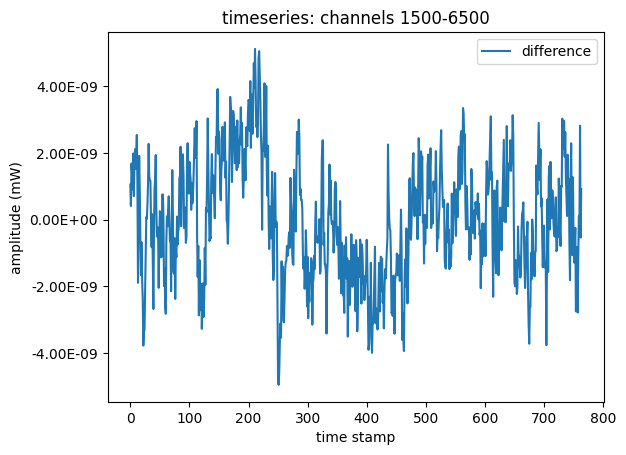

rms variation of difference = 1.765082379773903e-09


In [8]:
# creating the difference timeseries

dsp = (plsp1-(copt[0]*plsp2+dc1*copt[1]))/np.sqrt(2)

plt.figure()
plt.title('timeseries: channels '+str(chani)+'-'+str(chanf))
plt.xlabel('time stamp')
plt.ylabel('amplitude (mW)')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2E'))
plt.plot(dsp,label='difference')
plt.legend()
plt.draw()
plt.show()

print('rms variation of difference = {}'.format(np.std(dsp)))

**Calculating and plotting the power spectra of the difference timeseries and comparing it to those of the original timeseries**

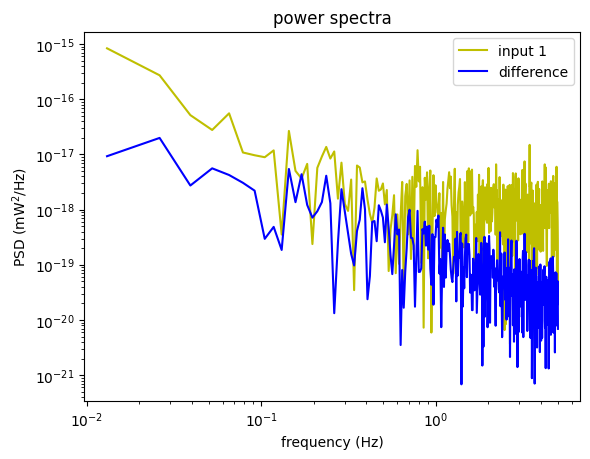

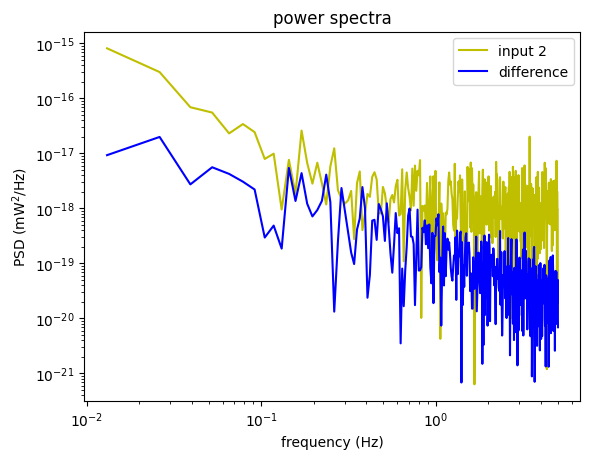

In [9]:
# power spectra of gain-matched inputs

Psp1 = (pow(np.absolute(np.fft.rfft(plsp1,norm='ortho')),2)*ts)[1:]
fsp1 = np.fft.rfftfreq(plsp1.shape[0],ts)[1:]

Psp2 = (pow(np.absolute(np.fft.rfft(plsp2,norm='ortho')),2)*ts)[1:]
fsp2 = np.fft.rfftfreq(plsp2.shape[0],ts)[1:]

# power spectrum of difference timeseries 

Psp = (pow(np.absolute(np.fft.rfft(dsp,norm='ortho')),2)*ts)[1:]
fsp = np.fft.rfftfreq(dsp.shape[0],ts)[1:]

plt.figure()
plt.title('power spectra')
plt.xlabel('frequency (Hz)')
plt.ylabel('PSD (mW$^2$/Hz)')
plt.semilogx()
plt.semilogy()
plt.plot(fsp1,Psp1,'-y',label='input 1')
plt.plot(fsp,Psp,'-b',label='difference')
plt.legend()
plt.draw()

plt.figure()
plt.title('power spectra')
plt.xlabel('frequency (Hz)')
plt.ylabel('PSD (mW$^2$/Hz)')
plt.semilogx()
plt.semilogy()
plt.plot(fsp2,Psp2,'-y',label='input 2')
plt.plot(fsp,Psp,'-b',label='difference')
plt.legend()
plt.show()